**Purpose:** S&P 500 buy-and-hold benchmark.

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


In [ ]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

class PortfolioMetrics_adapted:

    def __init__(self,
                 prices: pd.DataFrame,
                 risk_free_rate: str = str(PROJECT_ROOT / "01_data/aux/1M_TBills.csv"),
                 periods_per_year: int = 252):
        
        self.ppy = periods_per_year
        self.prices = prices

        self.returns = prices.pct_change()["2023-07-01":]
        self.assets = list(self.returns.columns)

        self.rf = (pd.read_csv(risk_free_rate)
           .set_index("observation_date")
           .pipe(lambda df: df.loc["2023-07-01":])
           .rename_axis(None)
           .pipe(lambda s: pd.to_datetime(s.index).to_series(index=s.index).pipe(lambda _: s.set_axis(pd.to_datetime(s.index))))
           .reindex(self.returns.index.tz_localize(None))
           .ffill()).values / 100

    def _validate_inputs(self, weights):
        expected_shape = (500, 1)
        if weights.shape != expected_shape:
            raise ValueError(f"weights shape {weights.shape} invalid (expected {expected_shape})")
        if weights.shape != self.returns.shape:
            raise ValueError(f"weights shape {weights.shape} does not match returns shape {self.returns.shape}")
        if not np.allclose(weights.sum(axis=1), 1.0):
            raise ValueError("weights do not sum to 1 along axis 1")
        return self.returns.values

    def _portfolio_returns(self, weights):
        r = self._validate_inputs(weights)
        return np.sum(weights * r, axis=1)
    
    def _cumulative_returns_overtime(self, weights):
        pr = self._portfolio_returns(weights)
        return np.cumprod(1 + pr)

    def cumulative_return(self, weights):
        pr = self._portfolio_returns(weights)
        return np.prod(1 + pr) - 1

    def volatility(self, weights):
        pr = self._portfolio_returns(weights)
        return np.std(pr) * np.sqrt(self.ppy)

    def sharpe_ratio(self, weights):
        pr = self._portfolio_returns(weights)
        excess = pr - self.rf / self.ppy
        return np.mean(excess) / (np.std(excess) + 1e-8) * np.sqrt(self.ppy)

    def max_drawdown(self, weights):
        pr = self._portfolio_returns(weights)
        cum = np.cumprod(1 + pr)
        peak = np.maximum.accumulate(cum)
        dd = (cum - peak) / peak
        return dd.min()

    def summary(self, weights):
        return {
            "cumulative_return": self.cumulative_return(weights),
            "volatility": self.volatility(weights),
            "sharpe_ratio": self.sharpe_ratio(weights),
            "max_drawdown": self.max_drawdown(weights),
        }
    
    def plot_weights(self, weights):
        fig, ax = plt.subplots(figsize=(14, 6))

        ax.stackplot(
            np.arange(500),
            weights.T,
            alpha=0.9
        )

        ax.set_xlim(0, 499)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Time (Days)")
        ax.set_ylabel("Weight (%)")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False
        )

        ax.set_title("Sector Composition Over Time")

        plt.tight_layout()
        plt.show()

    def plot_cumulative_returns(self, weights):
        cum = self._cumulative_returns_overtime(weights)

        fig, ax = plt.subplots(figsize=(14, 5))

        ax.plot(
            cum,
            color="black",
            linewidth=2
        )

        ax.set_xlim(0, len(cum) - 1)
        ax.set_xlabel("Time (Days)")
        ax.set_ylabel("Portfolio Value")

        ax.set_title("Cumulative Portfolio Return Over Time")

        # Optional: grid for readability
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

        plt.tight_layout()
        plt.show()

In [24]:
sp500_prices = yf.download("^GSPC", start="2023-06-30", end="2025-07-01")["Close"]

pm = PortfolioMetrics_adapted(prices=sp500_prices)

[*********************100%***********************]  1 of 1 completed


/var/folders/sz/96b_h5gn3y33k0c7jsvrstmm0000gn/T/ipykernel_48042/3762720298.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


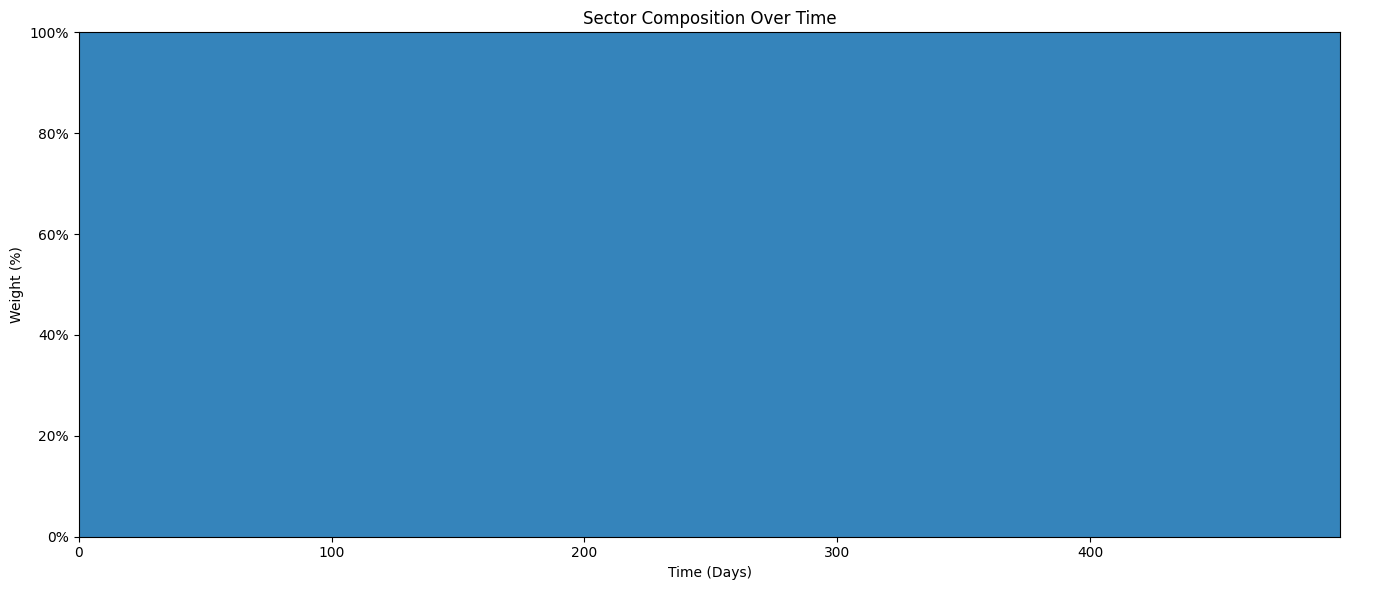

In [25]:
T, N = 500, 1
weights = np.full((T, N), 1 / N)

pm.plot_weights(weights)

In [26]:
pm.summary(weights)

{'cumulative_return': np.float64(0.3942518074190029),
 'volatility': np.float64(0.161071580651578),
 'sharpe_ratio': np.float64(0.8034739421156498),
 'max_drawdown': np.float64(-0.18902206184283987)}

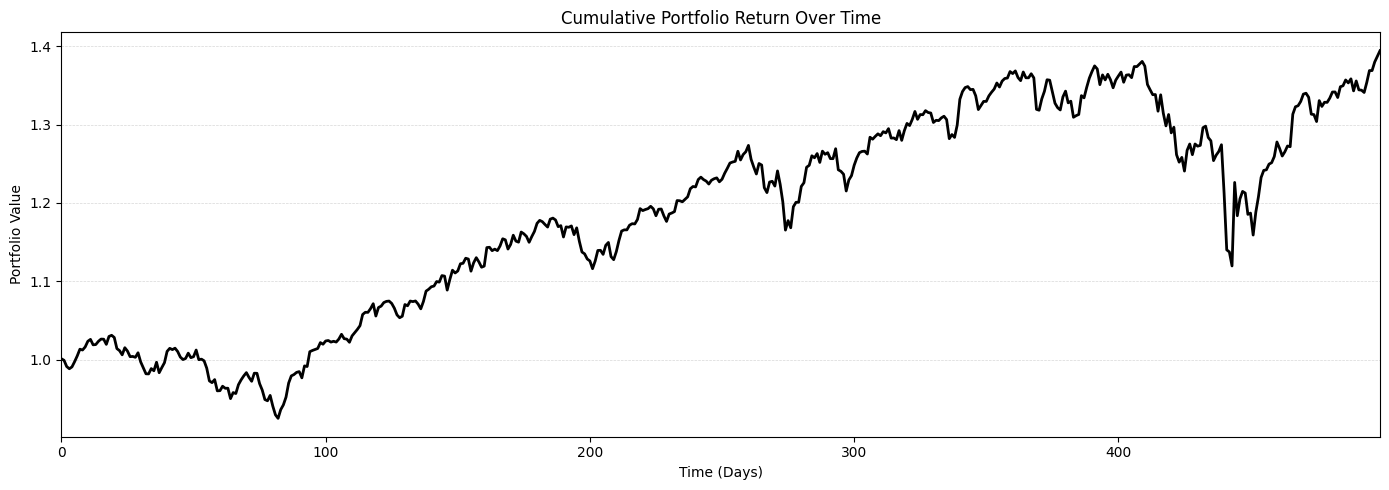

In [27]:
pm.plot_cumulative_returns(weights)